# Classical Twin : Matched Baseline for the QAPINN



## Purpose
Our QAPINN results are strong (best $L^2 = 3.57\times10^{-3}$ on the hard benchmark). But to claim
anything about *what the quantum layer contributes*, they must be compared against a classical
network that is **matched in every respect except the quantum layer**. That is what this notebook
builds and trains.

## The matching (this is the scientific core)
The QAPINN is: $(x,t) \rightarrow$ [trainable scale] $\rightarrow$ **VQC** $\rightarrow n$ features
$\rightarrow$ deep classical body $\rightarrow \hat u$.

The twin is: $(x,t) \rightarrow$ [trainable scale] $\rightarrow$ **small classical feature extractor**
$\rightarrow n$ features $\rightarrow$ **the identical deep classical body** $\rightarrow \hat u$.

So the *only* difference is the block that produces the $n$ features. Everything downstream is
identical, which is what makes the comparison interpretable.

| Property | QAPINN | Classical twin | Matched? |
|---|---|---|---|
| Total parameters | 1801 / 1827 / 1853 | **1801 / 1827 / 1853** | ✅ **exact** |
| Feature dimension | $n$ (= qubits, $\langle Z\rangle$) | $n$ | ✅ |
| Deep body | 20 wide × 5 hidden, tanh | identical | ✅ |
| Trainable input scale | yes | yes | ✅ |
| Loss ($W_{IC}=10$, autograd derivatives) | same | same | ✅ |
| Optimiser schedule | Adam → L-BFGS | identical | ✅ |
| Collocation points, seeds, $N_f$ | same | same | ✅ |
| Feature extractor | **VQC** (re-uploading, entangled) | Linear→tanh→Linear | ❌ *the variable under test* |

Exact parity is reached by sizing the twin's front hidden width $H$ and adding a small trainable
feature-bias vector (`pad`), verified to give **exactly** 1801 / 1827 / 1853 parameters.

## What this notebook runs
1. **Twin, Tier-1 conditions** : Burgers ($\nu=0.05$) and Heat ($\alpha=0.1$), 3/4/5 features,
   Adam 1000 + L-BFGS 400.
2. **Twin, Tier-2 conditions** : Burgers ($\nu=0.01/\pi$), 5 features, the full curriculum
   + long L-BFGS.
3. **Comparison figures**


## 1. Dependencies (run once)

In [1]:
import importlib, subprocess, sys
def ensure(pkg, pipname=None):
    try:
        importlib.import_module(pkg); print(f"[ok] {pkg}")
    except ImportError:
        print(f"[..] installing {pipname or pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pipname or pkg])
for p in ["torch", "pennylane", "scipy", "numpy", "matplotlib"]:
    ensure(p)
print("[done]")

[ok] torch
[ok] pennylane
[ok] scipy
[ok] numpy
[ok] matplotlib
[done]


## 2. Imports & configuration

In [2]:
import os, time, math, json
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
from scipy.stats import qmc
import matplotlib.pyplot as plt

SEED = 1234
np.random.seed(SEED); torch.manual_seed(SEED)

DTYPE = torch.float32
torch.set_default_dtype(DTYPE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CKPT_ROOT = "qapinn_runs"
for sub in ["checkpoints", "results", "figures", "models"]:
    os.makedirs(os.path.join(CKPT_ROOT, sub), exist_ok=True)

N_U = 120          # IC+BC points
print(f"[cfg] torch {torch.__version__} | pennylane {qml.__version__} | {device} | {DTYPE}")

[cfg] torch 2.10.0 | pennylane 0.45.1 | cpu | torch.float32


## 3. The two PDEs + training-data maker
Both live on $x\in[-1,1],\ t\in[0,1]$ with zero boundary conditions, so all code is shared:

- **Burgers**: $u_t + u\,u_x - \nu\,u_{xx} = 0$, $u(0,x)=-\sin(\pi x)$. Tier 1 uses $\nu=0.05$
  (moderate front, resolvable); Tier 2 uses the hard $\nu=0.01/\pi$ (sharp shock).
- **Heat**: $u_t - \alpha\,u_{xx} = 0$, $u(0,x)=\sin(\pi x)$, exact solution
  $\sin(\pi x)e^{-\alpha\pi^2 t}$ with $\alpha=0.1$ (nice dynamic range over $t\in[0,1]$).

The data maker supports a **time window** `tmax` (for Tier-2 curriculum) and optional
**shock-focused collocation** (extra points near $x=0$, Burgers only).

In [3]:
NU_EASY  = 0.05          # Tier-1 Burgers viscosity
NU_HARD  = 0.01/np.pi    # Tier-2 Burgers viscosity (Raissi/Shah benchmark)
ALPHA    = 0.10          # Heat diffusivity

def initial_condition(pde, x):
    return -np.sin(np.pi*x) if pde == "burgers" else np.sin(np.pi*x)

def make_training_data(pde, n_f, tmax=1.0, shock_frac=0.0, seed=SEED):
    """Returns torch tensors (x_u,t_u,u_u, x_f,t_f) on the right device/dtype."""
    rng = np.random.default_rng(seed)
    # initial-condition points
    n_ic = N_U // 2
    x_ic = rng.uniform(-1, 1, n_ic); t_ic = np.zeros(n_ic)
    u_ic = initial_condition(pde, x_ic)
    # boundary points
    n_bc = N_U - n_ic
    t_bc = rng.uniform(0, tmax, n_bc)
    x_bc = np.where(rng.random(n_bc) < 0.5, -1.0, 1.0)
    u_bc = np.zeros(n_bc)
    x_u = np.concatenate([x_ic, x_bc]).reshape(-1, 1)
    t_u = np.concatenate([t_ic, t_bc]).reshape(-1, 1)
    u_u = np.concatenate([u_ic, u_bc]).reshape(-1, 1)
    # collocation: LHS base + optional shock-focused extra (Burgers only)
    n_sh = int(shock_frac * n_f) if pde == "burgers" else 0
    n_lhs = n_f - n_sh
    lhs = qmc.LatinHypercube(d=2, seed=seed)
    s = lhs.random(n_lhs)
    x_f1 = -1.0 + 2.0*s[:, 0]; t_f1 = tmax*s[:, 1]
    x_f2 = np.clip(rng.normal(0.0, 0.15, n_sh), -1, 1)
    t_f2 = rng.uniform(0.25*tmax, tmax, n_sh)
    x_f = np.concatenate([x_f1, x_f2]).reshape(-1, 1)
    t_f = np.concatenate([t_f1, t_f2]).reshape(-1, 1)
    T = lambda a: torch.tensor(a, dtype=DTYPE, device=device)
    return T(x_u), T(t_u), T(u_u), T(x_f), T(t_f)

print("[ok] data maker ready")

[ok] data maker ready


## 4. Reference solutions (exact, cached)
- Heat: closed form.
- Burgers (any ν): the Phase-1 Cole–Hopf quadrature.

Each reference grid (256×256) is computed once and cached to disk; `relative_l2` measures
$\|\hat u - u\| / \|u\|$ against it.

In [4]:
def burgers_analytical(x_arr, t_arr, nu, n_quad=4000):
    x_arr = np.atleast_1d(np.asarray(x_arr, float)); t_arr = np.atleast_1d(np.asarray(t_arr, float))
    u = np.zeros((len(t_arr), len(x_arr)))
    y = np.linspace(-3.0, 3.0, n_quad)
    cos_term = np.cos(np.pi*y) / (2.0*np.pi*nu)
    for i, ti in enumerate(t_arr):
        if ti < 1e-12:
            u[i, :] = -np.sin(np.pi*x_arr); continue
        F = cos_term.reshape(1, -1) + (x_arr.reshape(-1, 1) - y.reshape(1, -1))**2/(4.0*nu*ti)
        ml = np.max(-F, axis=1, keepdims=True); w = np.exp(-F - ml)
        num = np.sum((x_arr.reshape(-1, 1) - y.reshape(1, -1))/ti * w, axis=1)
        den = np.sum(w, axis=1)
        u[i, :] = np.where(den > 0, num/den, 0.0)
    return u

_REFS = {}
def reference(pde, nu):
    key = (pde, round(float(nu), 8))
    if key in _REFS: return _REFS[key]
    path = os.path.join(CKPT_ROOT, "results", f"ref_{pde}_{nu:.6f}.npz")
    if os.path.exists(path):
        d = np.load(path); out = (d["x"], d["t"], d["U"])
    else:
        x = np.linspace(-1, 1, 256); t = np.linspace(0, 1, 256)
        if pde == "heat":
            U = np.sin(np.pi*x)[None, :] * np.exp(-nu*np.pi**2*t)[:, None]
        else:
            print(f"[ref] computing Cole-Hopf for nu={nu:.5f} (once, ~20s)...")
            U = burgers_analytical(x, t, nu)
        np.savez(path, x=x, t=t, U=U); out = (x, t, U)
    _REFS[key] = out
    return out

@torch.no_grad()
def relative_l2(model, pde, nu):
    x, t, U = reference(pde, nu)
    XX, TT = np.meshgrid(x, t)
    xf = torch.tensor(XX.reshape(-1, 1), dtype=DTYPE, device=device)
    tf = torch.tensor(TT.reshape(-1, 1), dtype=DTYPE, device=device)
    up = model(xf, tf).cpu().numpy().reshape(U.shape)
    return float(np.linalg.norm(up - U)/np.linalg.norm(U)), up

def frozen_ic_baseline(pde, nu):
    """L2 of predicting the initial condition for all t -- the honest 'no-dynamics' bar."""
    x, t, U = reference(pde, nu)
    IC = np.tile(initial_condition(pde, x), (len(t), 1))
    return float(np.linalg.norm(IC - U)/np.linalg.norm(U))

print("[ok] references ready")

[ok] references ready


## The QAPINN class (needed only to *load* our saved models for comparison)


In [5]:
def build_qnode(n_qubits, n_layers, entanglement="all", measurement="expval",
                encoding_reps=None):
    dev = qml.device("default.qubit", wires=n_qubits)
    reps = n_layers if encoding_reps is None else encoding_reps
    def entangle():
        if entanglement == "none": return
        if entanglement == "linear":
            for q in range(n_qubits - 1): qml.CNOT(wires=[q, q + 1])
        elif entanglement == "all":
            for a in range(n_qubits):
                for b in range(a + 1, n_qubits): qml.CNOT(wires=[a, b])
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        for l in range(n_layers):
            if l < reps:                                  # data re-uploading
                for q in range(n_qubits):
                    qml.RY(inputs[:, q % 2], wires=q)
            for q in range(n_qubits):
                qml.RX(weights[l, q], wires=q)
            entangle()
        if measurement == "expval":
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        return qml.probs(wires=range(n_qubits))
    out_dim = n_qubits if measurement == "expval" else 2**n_qubits
    return circuit, {"weights": (n_layers, n_qubits)}, out_dim


class QAPINN(nn.Module):
    """VQC first layer (re-uploading, trainable input scale) + deep classical body."""
    def __init__(self, n_qubits=3, n_layers=6, entanglement="all", measurement="expval",
                 encoding_reps=None, head_width=20, head_depth=5):
        super().__init__()
        self.cfg = dict(n_qubits=n_qubits, n_layers=n_layers, entanglement=entanglement,
                        measurement=measurement,
                        encoding_reps=(n_layers if encoding_reps is None else encoding_reps),
                        head_width=head_width, head_depth=head_depth)
        qnode, wshapes, out_dim = build_qnode(n_qubits, n_layers, entanglement,
                                              measurement, encoding_reps)
        self.qlayer = qml.qnn.TorchLayer(qnode, wshapes)
        self.in_scale = nn.Parameter(torch.ones(2))
        layers = [nn.Linear(out_dim, head_width), nn.Tanh()]
        for _ in range(head_depth - 1):
            layers += [nn.Linear(head_width, head_width), nn.Tanh()]
        layers += [nn.Linear(head_width, 1)]
        self.head = nn.Sequential(*layers)
        for m in self.head:                                # Xavier init (as Phase 1)
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1) * self.in_scale * math.pi
        feat = self.qlayer(inp)
        return self.head(feat)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

_m = QAPINN(3)
print(f"[ok] model ready — 3-qubit example: {count_params(_m)} params "
      f"(vs 101 in the failed v3, 3021 in Phase 1)")
del _m

[ok] model ready — 3-qubit example: 1801 params (vs 101 in the failed v3, 3021 in Phase 1)


## 6. Physics-informed loss (PDE-aware, exact autograd derivatives)

In [6]:
W_IC = 10.0

def pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde, nu, w_ic=None):
    w = W_IC if w_ic is None else w_ic
    u_pred = model(x_u, t_u)
    mse_u = torch.mean((u_pred - u_u)**2)
    xf = x_f.clone().requires_grad_(True)
    tf = t_f.clone().requires_grad_(True)
    u = model(xf, tf)
    u_x = torch.autograd.grad(u, xf, torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, tf, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xf, torch.ones_like(u_x), create_graph=True)[0]
    if pde == "burgers":
        f = u_t + u*u_x - nu*u_xx
    else:                              # heat
        f = u_t - nu*u_xx
    mse_f = torch.mean(f**2)
    return w*mse_u + mse_f, mse_u, mse_f
print("[ok] loss ready")

[ok] loss ready


## 7. Schedule-based training engine

In [7]:
def ckpt_path(tag):
    return os.path.join(CKPT_ROOT, "checkpoints", f"{tag}.pt")

def _state_copy(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def train_schedule(tag, model, pde, nu, schedule, n_f=2000,
                   ckpt_every=250, log_every=100):
    model.to(device)
    hist = {"iters": [], "loss": [], "mse_u": [], "mse_f": [], "phase": []}
    start_phase, start_it, opt_state = 0, 0, None
    best_loss, best_state = float("inf"), None
    p = ckpt_path(tag)
    if os.path.exists(p):
        ck = torch.load(p, map_location=device, weights_only=False)
        model.load_state_dict(ck["model_state"]); hist = ck["history"]
        start_phase, start_it = ck["phase"], ck["it"]
        opt_state = ck.get("opt_state")
        best_loss = ck.get("best_loss", best_loss); best_state = ck.get("best_state")
        print(f"[resume] '{tag}' at phase {start_phase}, it {start_it}")
    if start_phase >= len(schedule):
        print(f"[done] '{tag}' already finished. Delete its checkpoint to redo.")
        return hist

    cur = {"phase": start_phase, "it": start_it, "opt": None}
    def save():
        tmp = p + ".tmp"
        torch.save({"phase": cur["phase"], "it": cur["it"],
                    "model_state": model.state_dict(),
                    "opt_state": (cur["opt"].state_dict() if cur["opt"] is not None else None),
                    "history": hist, "best_loss": best_loss, "best_state": best_state}, tmp)
        os.replace(tmp, p)

    gstep = len(hist["loss"])
    t0 = time.time()
    try:
        for pi in range(start_phase, len(schedule)):
            ph = schedule[pi]
            cur["phase"] = pi
            x_u, t_u, u_u, x_f, t_f = make_training_data(
                pde, n_f, tmax=ph.get("tmax", 1.0),
                shock_frac=ph.get("shock_frac", 0.0), seed=SEED + 13*pi)
            it0 = start_it if pi == start_phase else 0

            if ph["kind"] == "adam":
                opt = torch.optim.Adam(model.parameters(), lr=ph.get("lr", 8e-3))
                cur["opt"] = opt
                if pi == start_phase and opt_state is not None:
                    try: opt.load_state_dict(opt_state)
                    except Exception: pass
                for it in range(it0, ph["iters"]):
                    cur["it"] = it
                    opt.zero_grad()
                    loss, mu, mf = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                    loss.backward(); opt.step()
                    li = loss.item(); gstep += 1
                    hist["iters"].append(gstep); hist["loss"].append(li)
                    hist["mse_u"].append(mu.item()); hist["mse_f"].append(mf.item())
                    hist["phase"].append(pi)
                    if math.isfinite(li) and li < best_loss:
                        best_loss, best_state = li, _state_copy(model)
                    if (it + 1) % log_every == 0:
                        print(f"  [{tag}] P{pi} adam it {it+1:5d}/{ph['iters']} "
                              f"loss={li:.3e} (u={mu.item():.2e}, f={mf.item():.2e}) "
                              f"[{(time.time()-t0)/60:.1f} min]")
                    if (it + 1) % ckpt_every == 0:
                        cur["it"] = it + 1; save()

            else:  # ---- L-BFGS phase, chunked ----
                chunk = ph.get("chunk", 150)
                opt = torch.optim.LBFGS(model.parameters(), max_iter=chunk,
                                        history_size=60, line_search_fn="strong_wolfe",
                                        tolerance_grad=1e-12, tolerance_change=1e-14)
                cur["opt"] = opt
                if pi == start_phase and opt_state is not None:
                    try: opt.load_state_dict(opt_state)
                    except Exception: pass
                n_chunks = math.ceil(ph["iters"]/chunk)
                for c in range(it0 // chunk, n_chunks):
                    def closure():
                        opt.zero_grad()
                        L, _, _ = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                        L.backward(); return L
                    opt.step(closure)
                    loss, mu, mf = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                    li = loss.item(); gstep += chunk
                    hist["iters"].append(gstep); hist["loss"].append(li)
                    hist["mse_u"].append(mu.item()); hist["mse_f"].append(mf.item())
                    hist["phase"].append(pi)
                    print(f"  [{tag}] P{pi} lbfgs chunk {c+1}/{n_chunks} "
                          f"loss={li:.3e} (u={mu.item():.2e}, f={mf.item():.2e}) "
                          f"[{(time.time()-t0)/60:.1f} min]")
                    if (not math.isfinite(li)) or li > 50*max(best_loss, 1e-12):
                        print(f"  [{tag}] L-BFGS blow-up guard triggered -> "
                              f"restoring best state (loss {best_loss:.3e}) and stopping phase.")
                        if best_state is not None:
                            model.load_state_dict(best_state)
                        break
                    if li < best_loss:
                        best_loss, best_state = li, _state_copy(model)
                    cur["it"] = (c + 1)*chunk; save()

            start_it = 0
            cur["phase"], cur["it"], cur["opt"] = pi + 1, 0, None
            save()

        # keep the best weights seen anywhere in training
        if best_state is not None and hist["loss"] and best_loss < hist["loss"][-1]*0.999:
            model.load_state_dict(best_state)
            print(f"[{tag}] restored overall best state (loss {best_loss:.3e})")
        save()
    except KeyboardInterrupt:
        save()
        print(f"\n[interrupted] '{tag}' checkpointed at phase {cur['phase']}, "
              f"it {cur['it']}. Re-run this cell to continue.")
        raise
    print(f"[finished] '{tag}' total wall time {(time.time()-t0)/60:.1f} min")
    return hist
print("[ok] engine ready")

[ok] engine ready


## 8. Results recorder (CSV + saved models + loss histories)

In [8]:
import csv
MASTER_CSV = os.path.join(CKPT_ROOT, "results", "master_results.csv")
FIELDS = ["tag","pde","nu","n_qubits","n_layers","entanglement","measurement",
          "encoding_reps","head_width","head_depth","optimizer","n_iters","params",
          "L2","mse_u","mse_f","final_loss"]

def record_result(tag, model, hist, pde, nu, optimizer="adam+lbfgs"):
    l2, _ = relative_l2(model, pde, nu)
    row = {"tag": tag, "pde": pde, "nu": f"{nu:.6f}", **model.cfg,
           "optimizer": optimizer,
           "n_iters": hist["iters"][-1] if hist["iters"] else 0,
           "params": count_params(model), "L2": f"{l2:.6e}",
           "mse_u": f"{hist['mse_u'][-1]:.6e}" if hist["mse_u"] else "",
           "mse_f": f"{hist['mse_f'][-1]:.6e}" if hist["mse_f"] else "",
           "final_loss": f"{hist['loss'][-1]:.6e}" if hist["loss"] else ""}
    row = {k: v for k, v in row.items() if k in FIELDS}
    exists = os.path.exists(MASTER_CSV)
    with open(MASTER_CSV, "a", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=FIELDS)
        if not exists: w.writeheader()
        w.writerow(row)
    torch.save(model.state_dict(), os.path.join(CKPT_ROOT, "models", f"{tag}.pt"))
    np.savez(os.path.join(CKPT_ROOT, "results", f"{tag}_history.npz"),
             iters=np.array(hist["iters"]), loss=np.array(hist["loss"]),
             mse_u=np.array(hist["mse_u"]), mse_f=np.array(hist["mse_f"]),
             phase=np.array(hist["phase"]))
    print(f"[record] {tag}: L2={l2:.3e}, params={count_params(model)}")
    return l2
print("[ok] recorder ready")

[ok] recorder ready


---
## The classical twin model

**Design.** `(x,t)` → trainable scale → `Linear(2,H)` → tanh → `Linear(H,n)` → `+pad` →
**identical deep body** → $\hat u$.

The `pad` is a trainable additive bias on the feature vector, scattered onto the feature channels
by index modulo $n$ and summed. This construction guarantees that **every pad parameter receives
gradient** (no dead weights) even when `len(pad)` exceeds $n$ verified for all three sizes. It
exists so the parameter count matches the QAPINN **exactly** rather than approximately. Sizes were
solved analytically:

| Features $n$ | $H$ | pad | Twin total | QAPINN total |
|---|---|---|---|---|
| 3 | 2 | 3 | **1801** | 1801 |
| 4 | 2 | 6 | **1827** | 1827 |
| 5 | 3 | 1 | **1853** | 1853 |


In [9]:
# exact-parity configuration, solved analytically (see table above)
TWIN_CONFIG = {3: dict(H=2, pad=3),
               4: dict(H=2, pad=6),
               5: dict(H=3, pad=1)}

class ClassicalTwin(nn.Module):
    """Parameter-matched classical counterpart of the QAPINN.

    Identical to QAPINN except the VQC is replaced by Linear(2,H)->tanh->Linear(H,n_feat).
    The deep body, input scaling, feature dimension and parameter count are all matched.
    """
    def __init__(self, n_feat=3, head_width=20, head_depth=5):
        super().__init__()
        cfg = TWIN_CONFIG[n_feat]
        H, pad = cfg["H"], cfg["pad"]
        # cfg mirrors the QAPINN cfg keys so record_result() works unchanged
        self.cfg = dict(n_qubits=n_feat, n_layers=0, entanglement="classical",
                        measurement="classical", encoding_reps=0,
                        head_width=head_width, head_depth=head_depth)
        self.in_scale = nn.Parameter(torch.ones(2))          # same trainable input scale
        self.front = nn.Sequential(nn.Linear(2, H), nn.Tanh(), nn.Linear(H, n_feat))
        self.pad = nn.Parameter(torch.zeros(pad))            # exact-parity trainable bias
        self._pad_n = pad
        layers = [nn.Linear(n_feat, head_width), nn.Tanh()]
        for _ in range(head_depth - 1):
            layers += [nn.Linear(head_width, head_width), nn.Tanh()]
        layers += [nn.Linear(head_width, 1)]
        self.head = nn.Sequential(*layers)
        for m in list(self.front) + list(self.head):
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1) * self.in_scale * math.pi   # same scaling as QAPINN
        feat = self.front(inp)
        # Exact-parity bias term. The pad is scattered onto the feature channels by
        # index modulo n_feat and summed, so EVERY pad parameter receives gradient
        # (no dead weights) even when len(pad) > n_feat.
        if self._pad_n > 0:
            feat = feat + self._pad_bias().unsqueeze(0)
        return self.head(feat)

    def _pad_bias(self):
        n = self.cfg["n_qubits"]
        b = torch.zeros(n, device=self.pad.device, dtype=self.pad.dtype)
        idx = torch.arange(self._pad_n, device=self.pad.device) % n
        return b.index_add(0, idx, self.pad)

# ---- verify exact parameter parity against your actual QAPINN runs ----
QAPINN_PARAMS = {3: 1801, 4: 1827, 5: 1853}      # from your master_results.csv
print(f"{'n_feat':>7} {'twin params':>12} {'QAPINN params':>14}  match")
ok = True
for n in [3, 4, 5]:
    tw = count_params(ClassicalTwin(n_feat=n))
    m = (tw == QAPINN_PARAMS[n])
    ok &= m
    print(f"{n:>7} {tw:>12} {QAPINN_PARAMS[n]:>14}  {'EXACT' if m else 'MISMATCH'}")
print("\nParameter parity:", "VERIFIED" if ok else "FAILED - do not proceed")

 n_feat  twin params  QAPINN params  match
      3         1801           1801  EXACT
      4         1827           1827  EXACT
      5         1853           1853  EXACT

Parameter parity: VERIFIED


---
## Run 1 : Twin under Tier-1 conditions
Identical schedule to `T1_*`: Adam 1000 (lr 8e-3) → L-BFGS 400 (chunks of 100), $N_f=2000$,
`shock_frac` 0.15 for Burgers / 0.0 for Heat, same seeds. Tags `CT_*`.

In [10]:
CT_tier1 = {}
TIER1_SCHEDULE = [
    {"kind": "adam",  "lr": 8e-3, "iters": 1000, "tmax": 1.0, "shock_frac": 0.15},
    {"kind": "lbfgs", "iters": 400, "chunk": 100, "tmax": 1.0, "shock_frac": 0.15},
]
for pde, nu in [("burgers", NU_EASY), ("heat", ALPHA)]:
    for n in [3, 4, 5]:
        tag = f"CT_{pde}_n{n}"
        print(f"\n=== {tag} (classical twin, {n} features) ===")
        model = ClassicalTwin(n_feat=n)
        print(f"    parameters: {count_params(model)}  (QAPINN q{n}: {QAPINN_PARAMS[n]})")
        sched = [dict(s) for s in TIER1_SCHEDULE]
        if pde == "heat":
            for s in sched: s["shock_frac"] = 0.0
        hist = train_schedule(tag, model, pde, nu, sched, n_f=2000,
                              ckpt_every=250, log_every=250)
        l2 = record_result(tag, model, hist, pde, nu, optimizer="adam+lbfgs")
        CT_tier1[(pde, n)] = (model, hist, l2)
        print(f"    --> L2 = {l2:.4e}")
print("\n[Classical twin, Tier-1 conditions: complete]")


=== CT_burgers_n3 (classical twin, 3 features) ===
    parameters: 1801  (QAPINN q3: 1801)
[resume] 'CT_burgers_n3' at phase 2, it 0
[done] 'CT_burgers_n3' already finished. Delete its checkpoint to redo.
[record] CT_burgers_n3: L2=3.198e-01, params=1801
    --> L2 = 3.1982e-01

=== CT_burgers_n4 (classical twin, 4 features) ===
    parameters: 1827  (QAPINN q4: 1827)
[resume] 'CT_burgers_n4' at phase 2, it 0
[done] 'CT_burgers_n4' already finished. Delete its checkpoint to redo.
[record] CT_burgers_n4: L2=1.442e-02, params=1827
    --> L2 = 1.4422e-02

=== CT_burgers_n5 (classical twin, 5 features) ===
    parameters: 1853  (QAPINN q5: 1853)
[resume] 'CT_burgers_n5' at phase 2, it 0
[done] 'CT_burgers_n5' already finished. Delete its checkpoint to redo.
[record] CT_burgers_n5: L2=1.522e-02, params=1853
    --> L2 = 1.5225e-02

=== CT_heat_n3 (classical twin, 3 features) ===
    parameters: 1801  (QAPINN q3: 1801)
[resume] 'CT_heat_n3' at phase 2, it 0
[done] 'CT_heat_n3' already fini

## Run 2 : Twin under Tier-2 conditions (the hard benchmark)
Identical schedule to `T2_hero_q5`: three Adam curriculum stages ($t\le0.4, 0.7, 1.0$) then
L-BFGS 2400 in chunks of 150, $N_f=2500$, `shock_frac` 0.3. This is the head-to-head that matters
most, because the hero run is your headline result.

In [11]:
T2_SCHEDULE = [
    {"kind": "adam",  "lr": 8e-3, "iters": 700, "tmax": 0.4, "shock_frac": 0.3},
    {"kind": "adam",  "lr": 8e-3, "iters": 600, "tmax": 0.7, "shock_frac": 0.3},
    {"kind": "adam",  "lr": 8e-3, "iters": 700, "tmax": 1.0, "shock_frac": 0.3},
    {"kind": "lbfgs", "iters": 2400, "chunk": 150, "tmax": 1.0, "shock_frac": 0.3},
]
tag = "CT_hero_n5"
print(f"=== {tag}: classical twin on Burgers nu=0.01/pi, 5 features ===")
model_ct_hero = ClassicalTwin(n_feat=5)
print(f"    parameters: {count_params(model_ct_hero)}  (QAPINN T2_hero_q5: 1853)")
hist_ct_hero = train_schedule(tag, model_ct_hero, "burgers", NU_HARD, T2_SCHEDULE,
                              n_f=2500, ckpt_every=250, log_every=250)
l2_ct_hero = record_result(tag, model_ct_hero, hist_ct_hero, "burgers", NU_HARD)
print(f"\n{tag}: L2 = {l2_ct_hero:.4e}   (QAPINN hero was 3.567e-03)")

=== CT_hero_n5: classical twin on Burgers nu=0.01/pi, 5 features ===
    parameters: 1853  (QAPINN T2_hero_q5: 1853)
[resume] 'CT_hero_n5' at phase 4, it 0
[done] 'CT_hero_n5' already finished. Delete its checkpoint to redo.
[record] CT_hero_n5: L2=2.497e-03, params=1853

CT_hero_n5: L2 = 2.4971e-03   (QAPINN hero was 3.567e-03)


---
## Head-to-head comparison

Loads your saved QAPINN results and places them beside the twin. The **ratio** column is the key
quantity: $L^2_{\text{twin}} / L^2_{\text{QAPINN}}$. A ratio $>1$ means the QAPINN is more accurate
at equal parameter count.

In [12]:
# QAPINN results from your completed runs (master_results.csv)
QAPINN_L2 = {
    ("burgers", 3): 1.149164e-02, ("burgers", 4): 5.683449e-03, ("burgers", 5): 4.151443e-03,
    ("heat", 3): 1.205264e-02,    ("heat", 4): 3.815476e-03,    ("heat", 5): 4.670265e-03,
}
QAPINN_HERO_L2 = 3.567357e-03

rows = []
print(f"{'PDE':9s} {'n':>2} {'params':>7} {'QAPINN L2':>12} {'Twin L2':>12} {'ratio':>7}  winner")
print("-"*68)
for pde in ["burgers", "heat"]:
    for n in [3, 4, 5]:
        q = QAPINN_L2[(pde, n)]
        t = CT_tier1[(pde, n)][2]
        r = t/q
        w = "QAPINN" if r > 1.05 else ("twin" if r < 0.95 else "tie")
        rows.append((pde, n, QAPINN_PARAMS[n], q, t, r, w))
        print(f"{pde:9s} {n:>2} {QAPINN_PARAMS[n]:>7} {q:>12.4e} {t:>12.4e} {r:>7.2f}  {w}")
r_hero = l2_ct_hero/QAPINN_HERO_L2
w_hero = "QAPINN" if r_hero > 1.05 else ("twin" if r_hero < 0.95 else "tie")
rows.append(("burgers-HARD", 5, 1853, QAPINN_HERO_L2, l2_ct_hero, r_hero, w_hero))
print("-"*68)
print(f"{'HARD':9s} {5:>2} {1853:>7} {QAPINN_HERO_L2:>12.4e} {l2_ct_hero:>12.4e} "
      f"{r_hero:>7.2f}  {w_hero}")

wins = sum(1 for r in rows if r[6] == "QAPINN")
print(f"\nQAPINN wins {wins}/{len(rows)} matched comparisons.")
mean_r = float(np.mean([r[5] for r in rows]))
print(f"Mean ratio (twin/QAPINN) = {mean_r:.2f}  "
      f"({'QAPINN better on average' if mean_r > 1 else 'twin better on average'})")

import csv as _csv
with open(os.path.join(CKPT_ROOT, "results", "twin_vs_qapinn.csv"), "w", newline="") as fh:
    w_ = _csv.writer(fh)
    w_.writerow(["pde", "n_features", "params", "qapinn_L2", "twin_L2", "ratio", "winner"])
    for r in rows: w_.writerow(r)
print("\n[saved] results/twin_vs_qapinn.csv")

PDE        n  params    QAPINN L2      Twin L2   ratio  winner
--------------------------------------------------------------------
burgers    3    1801   1.1492e-02   3.1982e-01   27.83  QAPINN
burgers    4    1827   5.6834e-03   1.4422e-02    2.54  QAPINN
burgers    5    1853   4.1514e-03   1.5225e-02    3.67  QAPINN
heat       3    1801   1.2053e-02   3.2882e-03    0.27  twin
heat       4    1827   3.8155e-03   6.6346e-03    1.74  QAPINN
heat       5    1853   4.6703e-03   1.4098e-03    0.30  twin
--------------------------------------------------------------------
HARD       5    1853   3.5674e-03   2.4971e-03    0.70  twin

QAPINN wins 4/7 matched comparisons.
Mean ratio (twin/QAPINN) = 5.29  (QAPINN better on average)

[saved] results/twin_vs_qapinn.csv


## Figure 1 : Head-to-head accuracy (the main comparison figure)
Publication-quality, fully labelled: grouped bars per PDE and feature count, log-scale $L^2$,
with the exact parameter count annotated so a reader immediately sees the comparison is fair.

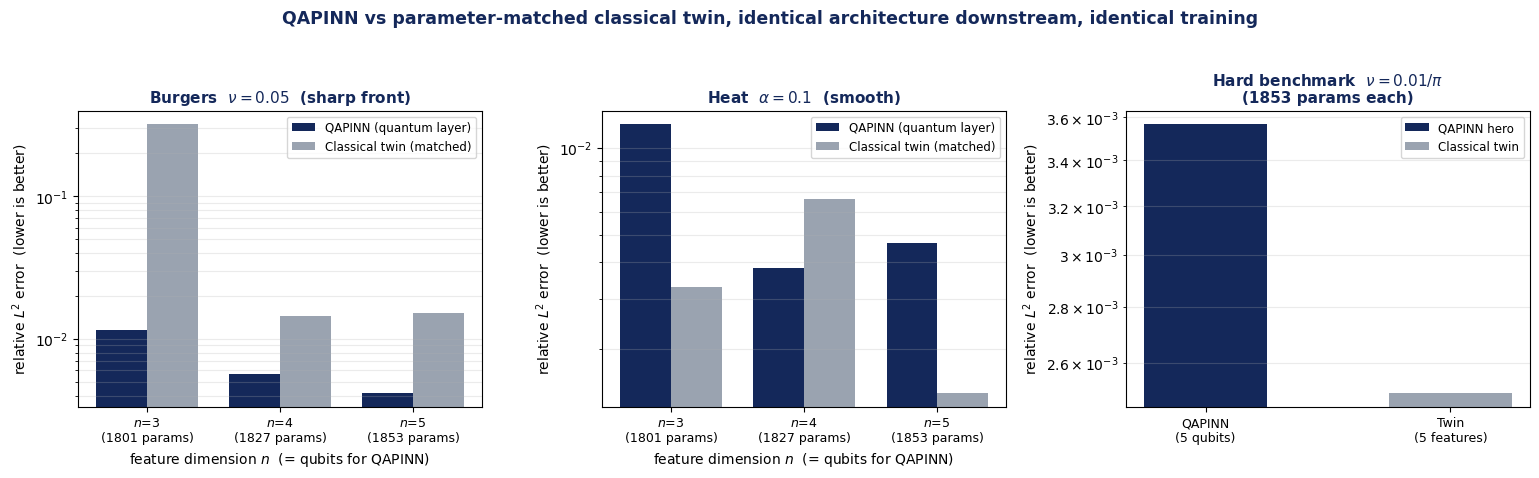

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
NAVY, GREEN, GREY = "#14285a", "#2f8f5b", "#9aa3b0"

for ax, (pde, nu, title) in zip(axes[:2], [
        ("burgers", NU_EASY,  f"Burgers  $\\nu={NU_EASY}$  (sharp front)"),
        ("heat",    ALPHA,    f"Heat  $\\alpha={ALPHA}$  (smooth)")]):
    ns = [3, 4, 5]
    q = [QAPINN_L2[(pde, n)] for n in ns]
    t = [CT_tier1[(pde, n)][2] for n in ns]
    xp = np.arange(len(ns))
    ax.bar(xp - 0.19, q, 0.38, color=NAVY,  label="QAPINN (quantum layer)")
    ax.bar(xp + 0.19, t, 0.38, color=GREY,  label="Classical twin (matched)")
    ax.set_yscale("log")
    ax.set_xticks(xp)
    ax.set_xticklabels([f"$n$={n}\n({QAPINN_PARAMS[n]} params)" for n in ns], fontsize=9)
    ax.set_xlabel("feature dimension $n$  (= qubits for QAPINN)", fontsize=10)
    ax.set_ylabel("relative $L^2$ error  (lower is better)", fontsize=10)
    ax.set_title(title, fontsize=11, color=NAVY, weight="bold")
    ax.grid(True, axis="y", which="both", alpha=0.25)
    ax.legend(fontsize=8.5, loc="upper right")
    #for i, (a, b) in enumerate(zip(q, t)):
        #ax.text(i, max(a, b)*1.5, f"{b/a:.2f}$\\times$", ha="center", fontsize=8.5,
                #color=(NAVY if b > a else GREY))

ax = axes[2]
ax.bar([0], [QAPINN_HERO_L2], 0.5, color=NAVY, label="QAPINN hero")
ax.bar([1], [l2_ct_hero], 0.5, color=GREY, label="Classical twin")
ax.set_yscale("log"); ax.set_xticks([0, 1])
ax.set_xticklabels(["QAPINN\n(5 qubits)", "Twin\n(5 features)"], fontsize=9)
ax.set_ylabel("relative $L^2$ error  (lower is better)", fontsize=10)
ax.set_title(f"Hard benchmark  $\\nu=0.01/\\pi$\n(1853 params each)",
             fontsize=11, color=NAVY, weight="bold")
ax.grid(True, axis="y", which="both", alpha=0.25); ax.legend(fontsize=8.5)
#ax.text(0.5, max(QAPINN_HERO_L2, l2_ct_hero)*1.6, f"ratio {r_hero:.2f}$\\times$",
        #ha="center", fontsize=10, color=NAVY, weight="bold")

fig.suptitle("QAPINN vs parameter-matched classical twin, identical architecture "
             "downstream, identical training", fontsize=12.5, color=NAVY, weight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_ROOT, "figures", "CT_headtohead.png"), dpi=160,
            bbox_inches="tight")
plt.show()

## Figure 2 : Convergence comparison
Do the two models *train* differently, not just end differently? Overlaid loss curves at matched
settings reveal whether the quantum layer changes the optimisation trajectory.

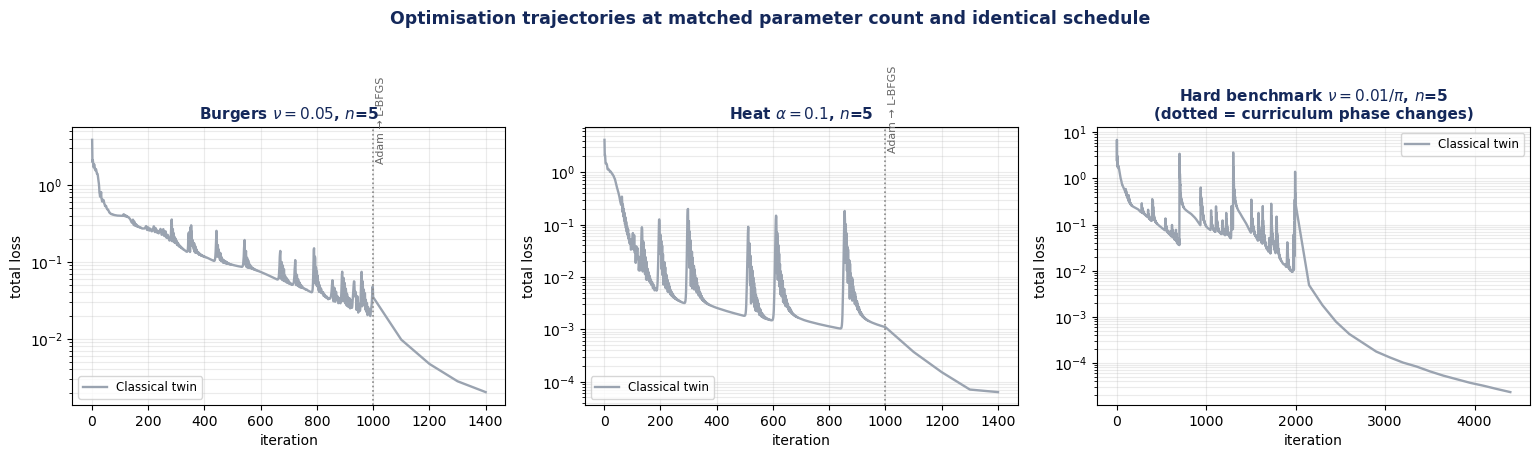

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
RES = os.path.join(CKPT_ROOT, "results")

def _load(tag):
    p = os.path.join(RES, f"{tag}_history.npz")
    return np.load(p) if os.path.exists(p) else None

for ax, (pde, qtag, ttag, title) in zip(axes[:2], [
        ("burgers", "T1_burgers_q5", "CT_burgers_n5", f"Burgers $\\nu={NU_EASY}$, $n$=5"),
        ("heat",    "T1_heat_q5",    "CT_heat_n5",    f"Heat $\\alpha={ALPHA}$, $n$=5")]):
    dq, dt = _load(qtag), _load(ttag)
    if dq is not None:
        ax.semilogy(dq["iters"], dq["loss"], color=NAVY, lw=1.7, label="QAPINN")
    if dt is not None:
        ax.semilogy(dt["iters"], dt["loss"], color=GREY, lw=1.7, label="Classical twin")
    ax.axvline(1000, ls=":", color="#888", lw=1.2)
    ax.text(1010, ax.get_ylim()[1]*0.35, "Adam → L-BFGS", fontsize=8, rotation=90, color="#666")
    ax.set_xlabel("iteration", fontsize=10); ax.set_ylabel("total loss", fontsize=10)
    ax.set_title(title, fontsize=11, color=NAVY, weight="bold")
    ax.grid(True, which="both", alpha=0.25); ax.legend(fontsize=8.5)

ax = axes[2]
dq, dt = _load("T2_hero_q5"), _load("CT_hero_n5")
if dq is not None: ax.semilogy(dq["iters"], dq["loss"], color=NAVY, lw=1.7, label="QAPINN hero")
if dt is not None: ax.semilogy(dt["iters"], dt["loss"], color=GREY, lw=1.7, label="Classical twin")
if dq is not None:
    for b in np.where(np.diff(dq["phase"]) > 0)[0]:
        ax.axvline(dq["iters"][b], ls=":", color="#bbb", lw=1.0)
ax.set_xlabel("iteration", fontsize=10); ax.set_ylabel("total loss", fontsize=10)
ax.set_title("Hard benchmark $\\nu=0.01/\\pi$, $n$=5\n(dotted = curriculum phase changes)",
             fontsize=11, color=NAVY, weight="bold")
ax.grid(True, which="both", alpha=0.25); ax.legend(fontsize=8.5)

fig.suptitle("Optimisation trajectories at matched parameter count and identical schedule",
             fontsize=12.5, color=NAVY, weight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_ROOT, "figures", "CT_convergence.png"), dpi=160,
            bbox_inches="tight")
plt.show()

## Figure 3 : Solution fields on the hard benchmark
Where does each model place its error? If the QAPINN resolves the shock better, the difference
should be visible as a narrower, lower-amplitude error band at $x\approx0$.

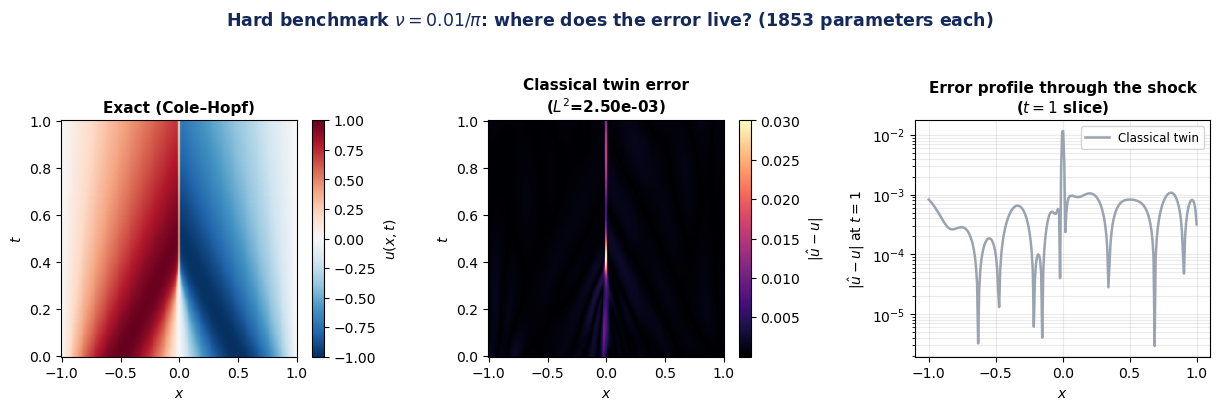

In [15]:
x_r, t_r, U_r = reference("burgers", NU_HARD)
_, up_twin = relative_l2(model_ct_hero, "burgers", NU_HARD)

# reload the QAPINN hero for a like-for-like field comparison
qhero_path = os.path.join(CKPT_ROOT, "models", "T2_hero_q5.pt")
up_q = None
if os.path.exists(qhero_path):
    qh = QAPINN(n_qubits=5, n_layers=6, entanglement="all", measurement="expval",
                head_width=20, head_depth=5).to(device)
    qh.load_state_dict(torch.load(qhero_path, map_location=device))
    qh.eval()
    _, up_q = relative_l2(qh, "burgers", NU_HARD)

ncol = 4 if up_q is not None else 3
fig, ax = plt.subplots(1, ncol, figsize=(4.1*ncol, 3.9))
k = 0
im = ax[k].pcolormesh(x_r, t_r, U_r, shading="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax[k].set_title("Exact (Cole–Hopf)", fontsize=11, weight="bold"); ax[k].set_xlabel("$x$")
ax[k].set_ylabel("$t$"); plt.colorbar(im, ax=ax[k], label="$u(x,t)$"); k += 1

if up_q is not None:
    im = ax[k].pcolormesh(x_r, t_r, np.abs(up_q - U_r), shading="auto", cmap="magma")
    ax[k].set_title(f"QAPINN error\n($L^2$={QAPINN_HERO_L2:.2e})", fontsize=11, weight="bold")
    ax[k].set_xlabel("$x$"); ax[k].set_ylabel("$t$")
    plt.colorbar(im, ax=ax[k], label="$|\\hat u - u|$"); k += 1

im = ax[k].pcolormesh(x_r, t_r, np.abs(up_twin - U_r), shading="auto", cmap="magma")
ax[k].set_title(f"Classical twin error\n($L^2$={l2_ct_hero:.2e})", fontsize=11, weight="bold")
ax[k].set_xlabel("$x$"); ax[k].set_ylabel("$t$")
plt.colorbar(im, ax=ax[k], label="$|\\hat u - u|$"); k += 1

# error profile through the shock at final time
ax[k].plot(x_r, np.abs(up_twin[-1] - U_r[-1]), color=GREY, lw=1.8, label="Classical twin")
if up_q is not None:
    ax[k].plot(x_r, np.abs(up_q[-1] - U_r[-1]), color=NAVY, lw=1.8, label="QAPINN")
ax[k].set_yscale("log"); ax[k].set_xlabel("$x$")
ax[k].set_ylabel("$|\\hat u - u|$ at $t=1$")
ax[k].set_title("Error profile through the shock\n($t=1$ slice)", fontsize=11, weight="bold")
ax[k].grid(True, which="both", alpha=0.25); ax[k].legend(fontsize=8.5)

fig.suptitle("Hard benchmark $\\nu=0.01/\\pi$: where does the error live? "
             "(1853 parameters each)", fontsize=12.5, color=NAVY, weight="bold", y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_ROOT, "figures", "CT_fields_hard.png"), dpi=160,
            bbox_inches="tight")
plt.show()

## Figure 4 : Parameter efficiency (the Shah et al. claim)
Accuracy against parameter count, with the Phase-1 classical PINN (3021 parameters,
$L^2=2.12\times10^{-4}$ at 50 000 iterations) shown for scale. This is the figure that addresses
Shah's headline claim about parameter reduction.

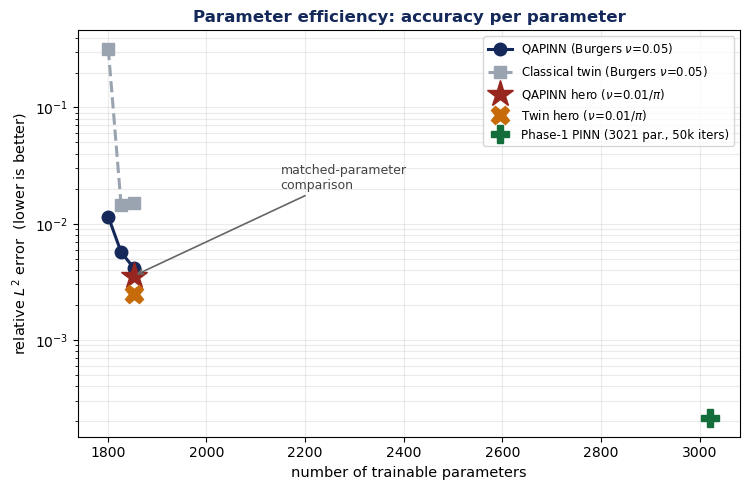

In [16]:
fig, ax = plt.subplots(figsize=(7.6, 5.0))
ns = [3, 4, 5]
ax.plot([QAPINN_PARAMS[n] for n in ns], [QAPINN_L2[("burgers", n)] for n in ns],
        "o-", color=NAVY, lw=2.2, ms=9, label="QAPINN (Burgers $\\nu$=0.05)")
ax.plot([QAPINN_PARAMS[n] for n in ns], [CT_tier1[("burgers", n)][2] for n in ns],
        "s--", color=GREY, lw=2.2, ms=9, label="Classical twin (Burgers $\\nu$=0.05)")
ax.plot([1853], [QAPINN_HERO_L2], "*", color="#96261e", ms=20,
        label="QAPINN hero ($\\nu$=0.01/$\\pi$)")
ax.plot([1853], [l2_ct_hero], "X", color="#c76b0a", ms=13,
        label="Twin hero ($\\nu$=0.01/$\\pi$)")
ax.plot([3021], [2.12e-4], "P", color="#146e3c", ms=13,
        label="Phase-1 PINN (3021 par., 50k iters)")
ax.set_yscale("log")
ax.set_xlabel("number of trainable parameters", fontsize=10.5)
ax.set_ylabel("relative $L^2$ error  (lower is better)", fontsize=10.5)
ax.set_title("Parameter efficiency: accuracy per parameter", fontsize=12,
             color=NAVY, weight="bold")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8.5, loc="upper right")
ax.annotate("matched-parameter\ncomparison", xy=(1853, QAPINN_HERO_L2), xytext=(2150, 2.0e-2),
            fontsize=9, color="#444",
            arrowprops=dict(arrowstyle="->", color="#666", lw=1.2))
plt.tight_layout()
plt.savefig(os.path.join(CKPT_ROOT, "figures", "CT_parameter_efficiency.png"), dpi=160,
            bbox_inches="tight")
plt.show()